# Causal Inference for AI — Week 2
## Causal Graphs, $d$-Separation, and the Back-Door Criterion

Week 1 told us *that* we must adjust for confounders. It did **not** tell us *which*
variables are confounders, which are harmless, and which would actively **create** bias if
we conditioned on them. Answering that requires a language for causal structure:
**Directed Acyclic Graphs (DAGs)**.

In this notebook we build, from scratch:
- a tiny DAG engine (parents, descendants, topological order);
- a **$d$-separation** oracle that reads conditional independencies off the graph;
- the three canonical structures — **chain, fork, collider** — and the counter-intuitive
  *collider bias*;
- the **back-door criterion** and an algorithm that searches for a valid adjustment set;
- empirical confirmation that adjusting the *right* set recovers the effect and the *wrong*
  set destroys it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = default_rng(0)
print("Environment ready — NumPy", np.__version__)

Environment ready — NumPy 2.4.4


## 1. A minimal DAG class

A DAG is just nodes + directed edges with no cycles. We store it as adjacency sets and
provide the graph primitives $d$-separation needs.

In [2]:
class DAG:
    def __init__(self, edges):
        self.children = {}
        self.parents = {}
        self.nodes = set()
        for a, b in edges:
            self.nodes |= {a, b}
            self.children.setdefault(a, set()).add(b)
            self.parents.setdefault(b, set()).add(a)
        for n in self.nodes:
            self.children.setdefault(n, set())
            self.parents.setdefault(n, set())
        assert self._acyclic(), "graph contains a cycle!"

    def _acyclic(self):
        color = {n: 0 for n in self.nodes}        # 0=white,1=gray,2=black
        def visit(u):
            color[u] = 1
            for v in self.children[u]:
                if color[v] == 1: return False
                if color[v] == 0 and not visit(v): return False
            color[u] = 2
            return True
        return all(visit(n) for n in self.nodes if color[n] == 0)

    def ancestors(self, x):
        out, stack = set(), list(self.parents[x])
        while stack:
            p = stack.pop()
            if p not in out:
                out.add(p); stack += list(self.parents[p])
        return out

    def neighbors_undirected(self, x):
        return self.children[x] | self.parents[x]

g = DAG([("Z","X"), ("Z","Y"), ("X","Y")])
print("nodes   :", sorted(g.nodes))
print("parents of Y:", g.parents["Y"])
print("ancestors of Y:", g.ancestors("Y"))

nodes   : ['X', 'Y', 'Z']
parents of Y: {'Z', 'X'}
ancestors of Y: {'Z', 'X'}


## 2. $d$-separation from scratch

$d$-separation is the rule that translates **graph structure** into **conditional
independence**. A path is *blocked* given a conditioning set $Z$ if it contains:

- a **chain** $a\to m\to b$ or **fork** $a\leftarrow m\to b$ with $m\in Z$, **or**
- a **collider** $a\to m\leftarrow b$ with $m\notin Z$ **and** no descendant of $m$ in $Z$.

$X$ and $Y$ are $d$-separated given $Z$ ($X\perp_d Y\mid Z$) iff **every** path between them
is blocked. We implement the classic **Bayes-Ball / reachability** algorithm: do a search
over (node, direction) states, respecting how each junction passes or blocks the ball.

In [3]:
def d_separated(dag, X, Y, Z=()):
    X = {X} if isinstance(X, str) else set(X)
    Y = {Y} if isinstance(Y, str) else set(Y)
    Z = set(Z)

    # Precompute: a node is an 'active collider' if it or a descendant is in Z.
    z_or_anc = set(Z)
    for z in Z:
        z_or_anc |= dag.ancestors(z)

    # BFS over (node, arriving_direction). dir 'up' = arrived via a child->node edge
    # (i.e., moving against arrows); 'down' = arrived via parent->node edge.
    from collections import deque
    visited = set()
    queue = deque()
    for x in X:
        queue.append((x, "up"))      # seed: think of starting by going outward
    while queue:
        node, d = queue.popleft()
        if (node, d) in visited: continue
        visited.add((node, d))
        if node in Y:
            return False             # reachable => NOT d-separated
        if d == "up":                # arrived moving up (child side)
            if node not in Z:
                for p in dag.parents[node]:  queue.append((p, "up"))
                for c in dag.children[node]: queue.append((c, "down"))
        else:                        # d == 'down', arrived via a parent
            if node not in Z:
                for c in dag.children[node]: queue.append((c, "down"))
            if node in z_or_anc:     # collider opened by conditioning
                for p in dag.parents[node]:  queue.append((p, "up"))
    return True

# Confounding triangle Z->X, Z->Y, X->Y
print("X ⟂ Y | ∅  ?", d_separated(g, "X", "Y"))        # False (direct edge + back-door)
print("X ⟂ Y | Z  ?", d_separated(g, "X", "Y", {"Z"})) # False (direct edge remains)

X ⟂ Y | ∅  ? False
X ⟂ Y | Z  ? False


### Validating the oracle against the three canonical structures

We test the engine on chain, fork, and collider, where the answers are textbook. We also
test the **collider's descendant** subtlety.

In [4]:
chain    = DAG([("X","M"), ("M","Y")])             # X -> M -> Y
fork     = DAG([("M","X"), ("M","Y")])             # X <- M -> Y
collider = DAG([("X","M"), ("Y","M")])             # X -> M <- Y
coll_desc= DAG([("X","M"), ("Y","M"), ("M","D")])  # collider M with child D

checks = [
    ("chain    X⟂Y|∅",  d_separated(chain,"X","Y"),          False),
    ("chain    X⟂Y|M",  d_separated(chain,"X","Y",{"M"}),    True ),
    ("fork     X⟂Y|∅",  d_separated(fork,"X","Y"),           False),
    ("fork     X⟂Y|M",  d_separated(fork,"X","Y",{"M"}),     True ),
    ("collider X⟂Y|∅",  d_separated(collider,"X","Y"),       True ),
    ("collider X⟂Y|M",  d_separated(collider,"X","Y",{"M"}), False),  # opens the path!
    ("collider X⟂Y|desc",d_separated(coll_desc,"X","Y",{"D"}),False), # descendant opens it
]
for name, got, want in checks:
    flag = "OK " if got == want else "XX "
    print(f"{flag}{name:22s} -> {got}  (expected {want})")
assert all(got == want for _,got,want in checks), "d-sep oracle disagrees with theory!"
print("\nAll d-separation results match the textbook. Oracle verified.")

OK chain    X⟂Y|∅         -> False  (expected False)
OK chain    X⟂Y|M         -> True  (expected True)
OK fork     X⟂Y|∅         -> False  (expected False)
OK fork     X⟂Y|M         -> True  (expected True)
OK collider X⟂Y|∅         -> True  (expected True)
OK collider X⟂Y|M         -> False  (expected False)
OK collider X⟂Y|desc      -> False  (expected False)

All d-separation results match the textbook. Oracle verified.


## 3. Collider bias is real — a numerical demonstration

The most dangerous mistake in applied ML is "control for everything you have." A collider
$X\to M\leftarrow Y$ starts with $X\perp Y$, but **conditioning on $M$ induces a spurious
association**. We simulate two independent causes of a common effect and watch a correlation
appear out of thin air the moment we slice on the collider.

corr(X, Y) unconditional      : +0.015  (≈0, independent)
corr(X, Y) | admitted (M high): -0.547  (spurious!)


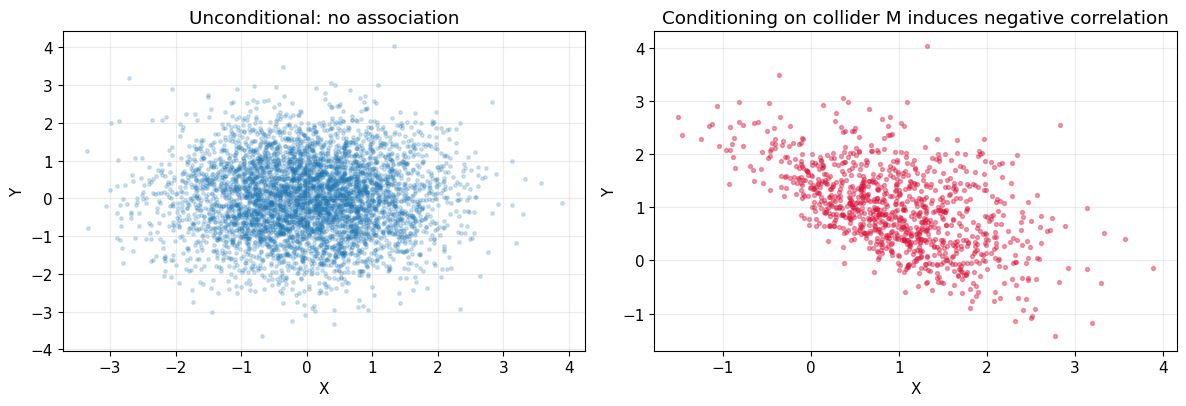

In [5]:
g2 = default_rng(3)
n = 5000
X = g2.normal(0, 1, n)             # e.g., talent
Yc = g2.normal(0, 1, n)            # e.g., beauty  (independent of X by construction)
M = X + Yc + g2.normal(0, .3, n)   # collider: 'got hired by a selective firm'

print(f"corr(X, Y) unconditional      : {np.corrcoef(X, Yc)[0,1]:+.3f}  (≈0, independent)")
top = M > np.quantile(M, .8)       # condition on the collider (only the admitted)
print(f"corr(X, Y) | admitted (M high): {np.corrcoef(X[top], Yc[top])[0,1]:+.3f}  (spurious!)")

fig, ax = plt.subplots(1,2, figsize=(12,4.2))
ax[0].scatter(X, Yc, s=6, alpha=.2); ax[0].set(title="Unconditional: no association")
ax[1].scatter(X[top], Yc[top], s=8, alpha=.4, color="crimson")
ax[1].set(title="Conditioning on collider M induces negative correlation")
for a in ax: a.set(xlabel="X", ylabel="Y")
plt.tight_layout(); plt.savefig("../figures/w2_collider.png", dpi=110); plt.show()

## 4. The back-door criterion

A set $Z$ satisfies the **back-door criterion** relative to $(X,Y)$ if:

1. no node in $Z$ is a **descendant** of $X$, and
2. $Z$ **blocks every path** between $X$ and $Y$ that begins with an arrow *into* $X$
   (a "back-door" path).

If such $Z$ exists, the interventional distribution is identified by adjustment:

$$ P\big(Y \mid \mathrm{do}(X=x)\big) = \sum_z P(Y\mid X=x, Z=z)\,P(Z=z). $$

We implement a checker by building the graph with $X$'s **outgoing** edges removed (so we
only test back-door paths) and reusing our $d$-separation oracle.

In [6]:
def satisfies_backdoor(dag, X, Y, Z):
    Z = set(Z)
    # (1) no Z is a descendant of X
    desc_X = set()
    stack = list(dag.children[X])
    while stack:
        c = stack.pop()
        if c not in desc_X:
            desc_X.add(c); stack += list(dag.children[c])
    if Z & desc_X:
        return False
    # (2) block all back-door paths: delete X's outgoing edges, test d-sep of X,Y | Z
    edges = [(a,b) for a in dag.children for b in dag.children[a] if a != X]
    g_back = DAG(edges) if edges else dag
    for node in dag.nodes:           # ensure isolated nodes survive
        g_back.nodes.add(node); g_back.children.setdefault(node,set()); g_back.parents.setdefault(node,set())
    return d_separated(g_back, X, Y, Z)

# Confounder graph: Z is the classic valid adjustment set.
gc = DAG([("Z","X"), ("Z","Y"), ("X","Y")])
print("Z={Z}  valid back-door set? ", satisfies_backdoor(gc,"X","Y",{"Z"}))   # True
print("Z={}   valid back-door set? ", satisfies_backdoor(gc,"X","Y",set()))   # False

Z={Z}  valid back-door set?  True
Z={}   valid back-door set?  False


In [7]:
def find_backdoor_sets(dag, X, Y):
    """Brute-force search over candidate adjustment sets (small graphs only)."""
    from itertools import combinations
    candidates = sorted(dag.nodes - {X, Y})
    valid = []
    for r in range(len(candidates)+1):
        for combo in combinations(candidates, r):
            if satisfies_backdoor(dag, X, Y, set(combo)):
                valid.append(set(combo))
    return valid

# A richer graph: confounder Z, a mediator M (X->M->Y), and a collider C (X->C<-Y).
g_rich = DAG([("Z","X"),("Z","Y"),("X","M"),("M","Y"),("X","C"),("Y","C")])
for s in find_backdoor_sets(g_rich, "X", "Y"):
    print("valid adjustment set:", s if s else "{} (empty)")
print()
print("Note: {Z} works; sets containing the mediator M or collider C are correctly rejected.")

valid adjustment set: {'Z'}

Note: {Z} works; sets containing the mediator M or collider C are correctly rejected.


## 5. Putting it together: right set vs. wrong set

We now generate data from `g_rich` and compare three adjustment strategies, scoring each
against the known structural effect of $X$ on $Y$:

- adjust for $\{Z\}$ — **correct** back-door set;
- adjust for $\{Z, M\}$ — **over-control**: $M$ is a mediator, blocking part of the effect;
- adjust for $\{Z, C\}$ — **collider bias**: $C$ opens a spurious path.

In [8]:
def ols_coef(Xmat, y):
    Xmat = np.column_stack([np.ones(len(Xmat)), Xmat])
    beta, *_ = np.linalg.lstsq(Xmat, y, rcond=None)
    return beta

g3 = default_rng(7)
N = 40000
Z = g3.normal(0,1,N)
X = 0.8*Z + g3.normal(0,1,N)
TRUE_EFFECT = 2.0                       # structural coefficient X->Y (direct + via M)
M = 1.0*X + g3.normal(0,1,N)            # mediator
# Total effect of X on Y = direct(1.0) + via M (1.0 * 1.0) = 2.0
Y = 1.0*X + 1.0*M + 1.5*Z + g3.normal(0,1,N)
C = 1.0*X + 1.0*Y + g3.normal(0,1,N)    # collider (post-treatment, post-outcome)

def effect_adjusting_for(cols):
    design = np.column_stack([X] + cols) if cols else X.reshape(-1,1)
    return ols_coef(design, Y)[1]

print(f"TRUE total effect of X on Y      : {TRUE_EFFECT:.2f}")
print(f"adjust {{}}        (confounded)   : {effect_adjusting_for([]):.3f}")
print(f"adjust {{Z}}       (correct)      : {effect_adjusting_for([Z]):.3f}")
print(f"adjust {{Z, M}}    (over-control) : {effect_adjusting_for([Z, M]):.3f}")
print(f"adjust {{Z, C}}    (collider bias): {effect_adjusting_for([Z, C]):.3f}")

TRUE total effect of X on Y      : 2.00
adjust {}        (confounded)   : 2.727
adjust {Z}       (correct)      : 1.998
adjust {Z, M}    (over-control) : 1.005
adjust {Z, C}    (collider bias): 0.003


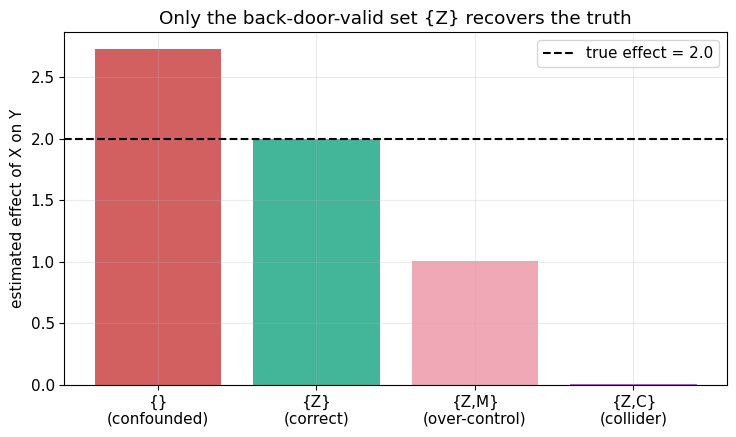

'Control for everything' is provably wrong: M and C each inject bias.


In [9]:
labels = ["{}\n(confounded)", "{Z}\n(correct)", "{Z,M}\n(over-control)", "{Z,C}\n(collider)"]
vals = [effect_adjusting_for([]), effect_adjusting_for([Z]),
        effect_adjusting_for([Z,M]), effect_adjusting_for([Z,C])]
colors = ["#c44","#2a8","#e9a","#a4c"]
plt.bar(labels, vals, color=colors, alpha=.85)
plt.axhline(TRUE_EFFECT, color="k", ls="--", label=f"true effect = {TRUE_EFFECT}")
plt.ylabel("estimated effect of X on Y"); plt.legend()
plt.title("Only the back-door-valid set {Z} recovers the truth")
plt.tight_layout(); plt.savefig("../figures/w2_adjustment.png", dpi=110); plt.show()
print("'Control for everything' is provably wrong: M and C each inject bias.")

## Summary & what's next

- A **DAG** encodes causal structure; we built one and verified acyclicity.
- **$d$-separation** reads conditional independence off the graph; our from-scratch oracle
  matches the textbook on chains, forks, colliders, and the descendant-of-collider case.
- **Collider bias** is not a curiosity — conditioning on a common effect manufactures
  associations; we watched a zero correlation become strongly nonzero.
- The **back-door criterion** identifies *which* variables to adjust for; our search finds
  all valid sets and rejects mediators and colliders.
- Empirically, only the back-door-valid set recovered the true effect; "adjust for
  everything" was biased in two distinct ways.

**Exercises.** (1) Add an unobserved confounder $U\to X$, $U\to Y$ and show no observable
set satisfies the back-door criterion — motivating instruments (Week 6). (2) Implement the
**front-door** criterion and test it on a graph with an unobserved confounder but an
observed mediator. (3) Extend `find_backdoor_sets` to return the *minimal* sets only.

**Week 3:** now that we know *what* to adjust for, we learn *how* with real estimators —
inverse-propensity weighting, matching, and the doubly-robust AIPW estimator.